In [1]:
# Importin necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from IPython.display import display 

from sklearn.impute import SimpleImputer
from scipy.stats import mstats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Reading the dataset
df = pd.read_csv('marketing_campaign.csv',sep='\t')
df.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,...,20,1,0,0,0,0,0,3,11,0


In [3]:
# General information of each column in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Shows descriptive statistics such as mean, standard deviation, Q1, Q3, min, and max
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [5]:
# Drop the ID column - it has no value
# Drop both Z_CostContact and Z_Revenue - their values are all the same, no correlation
df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], inplace=True)

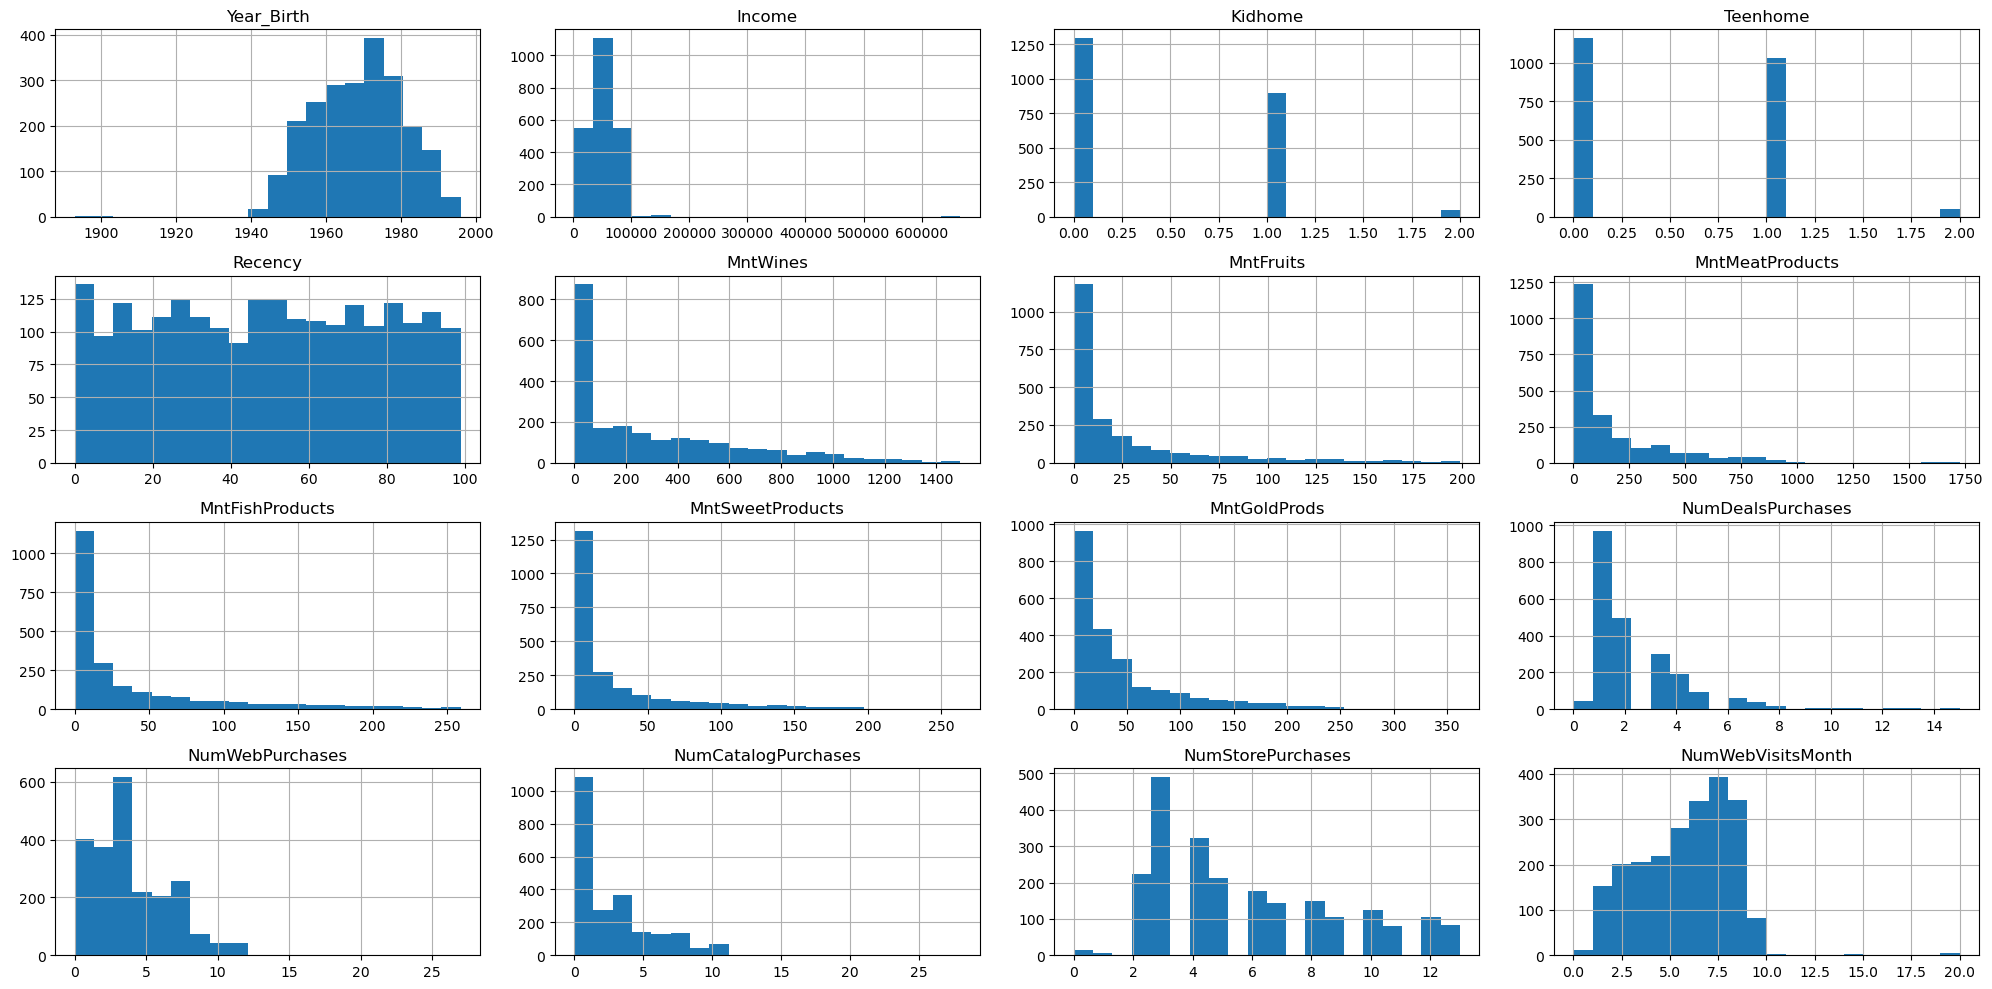

In [6]:
drop_columns = ['Education', 'Marital_Status', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Response']
df.drop(columns=drop_columns).hist(bins=20, figsize=(20, 10)) 
plt.tight_layout() 
plt.show()

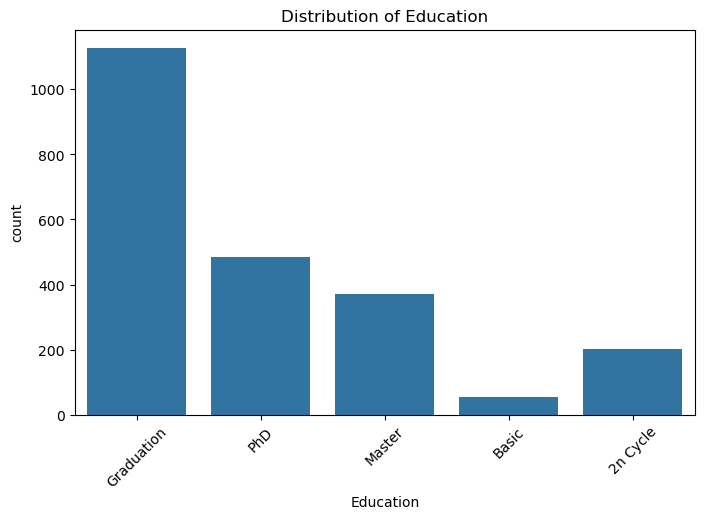

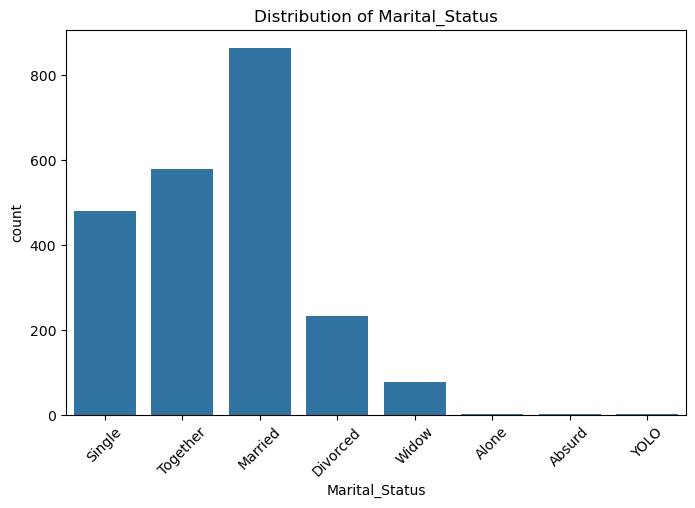

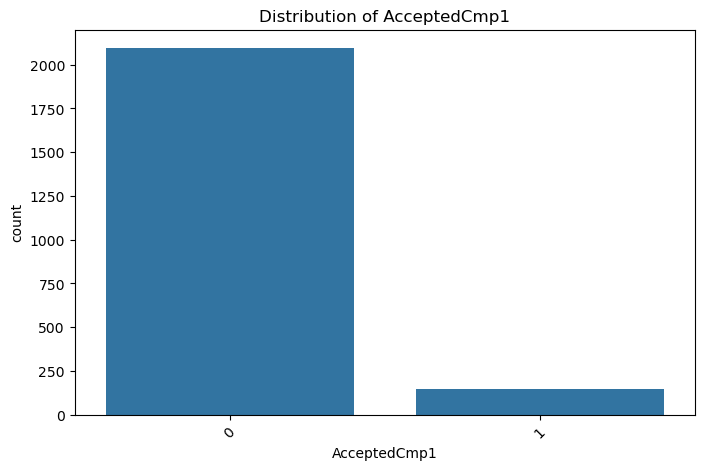

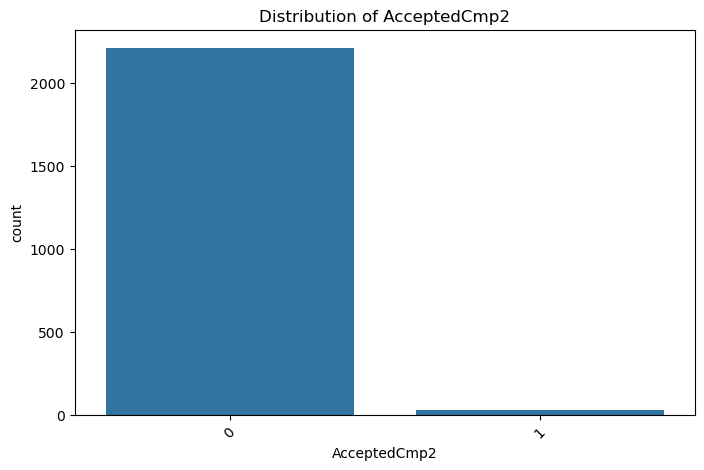

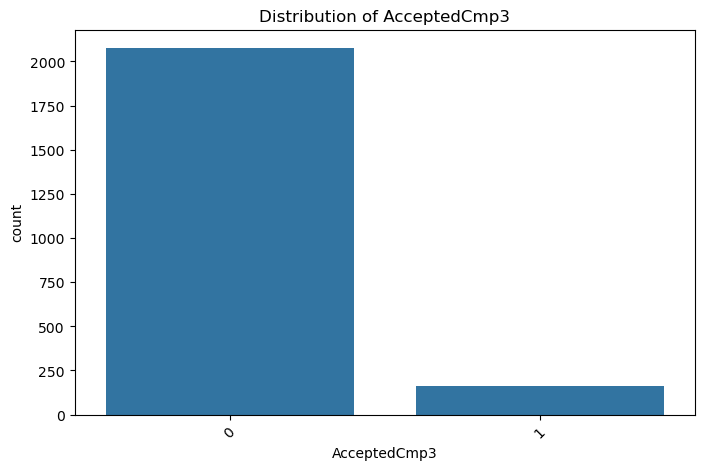

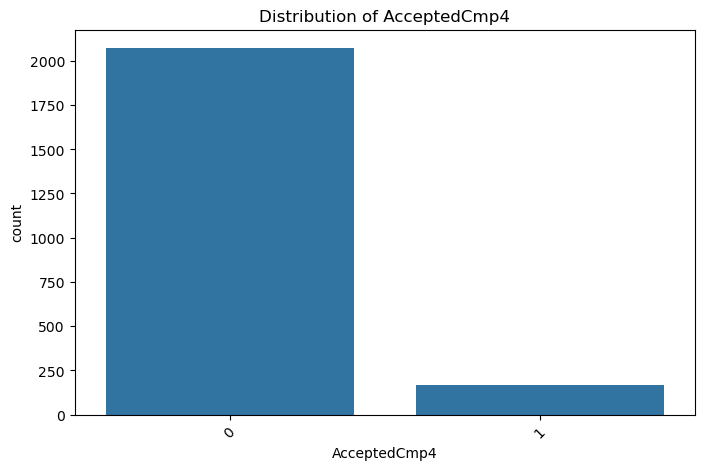

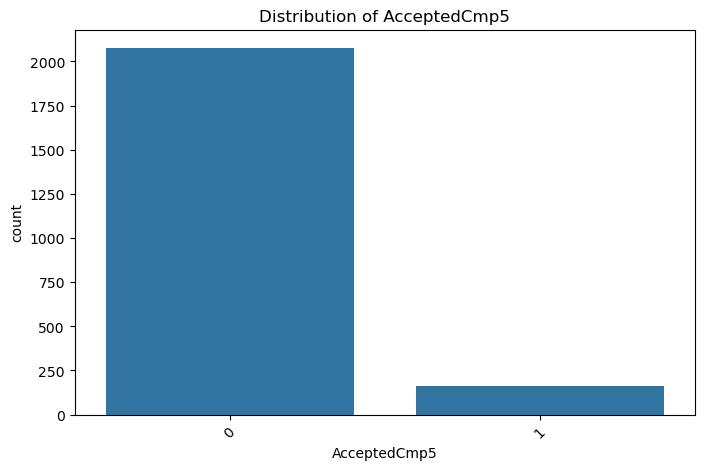

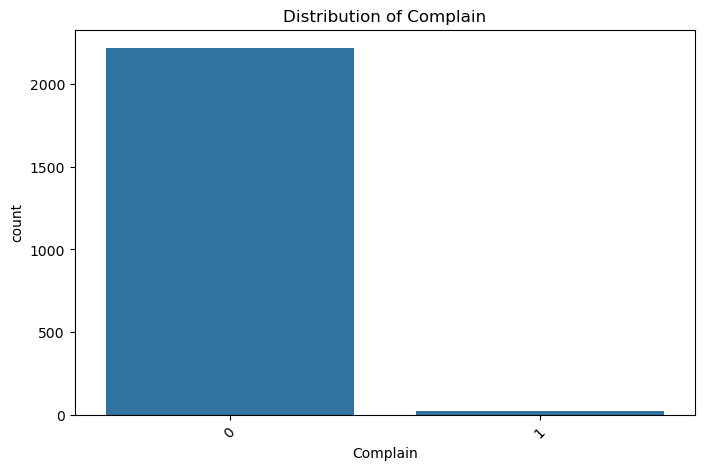

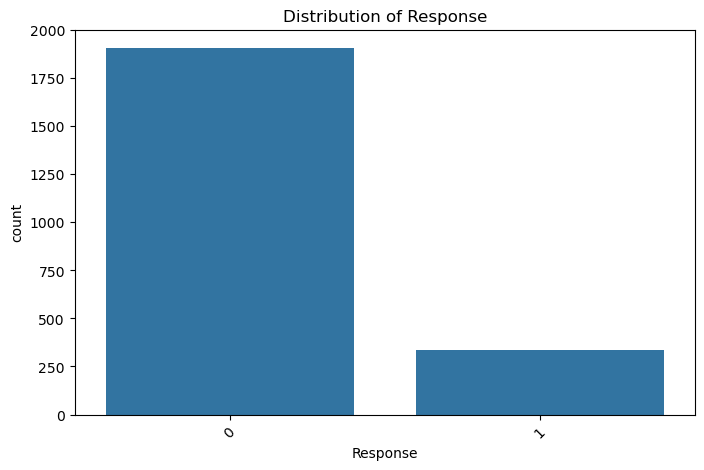

In [7]:
columns_to_plot = ["Education", "Marital_Status", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain", "Response"]
for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45) # Helps if category names are long
    plt.show()

In [8]:
# Checks what columns have missing values
df.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

In [9]:
# Applying the simple imputer algorithm to the income column to give all null values the value of the mean income
imputer = SimpleImputer(strategy='mean')
df[['Income']] = imputer.fit_transform(df[['Income']])

In [10]:
# Find all types of values for categorical columns
all_education_categories = df['Education'].unique()
print(all_education_categories)
all_marital_status_categories = df['Marital_Status'].unique()
print(all_marital_status_categories)

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [11]:
# Convert all categorical values to lowercase
df['Education'] = df['Education'].str.lower()
df['Marital_Status'] = df['Marital_Status'].str.lower()

In [12]:
# Convert all categorical values into integers
# Convert education data to ranking data (basic is closer to graducation, master is closer to phd, DBSCAN model requires this)
df['Education'] = df['Education'].map({'basic': 0, 'graduation': 1, '2n cycle':2, 'master':3, 'phd':4})

In [13]:
#Create 3 groups for marital status
single_values = ['alone','absurd','yolo','single']
df['Marital_Status'] = df['Marital_Status'].replace(single_values, 'Single')

partnered_values = ['together','married']
df['Marital_Status'] = df['Marital_Status'].replace(partnered_values, 'Partnered')

post_partnered_values = ['widow','divorced']
df['Marital_Status'] = df['Marital_Status'].replace(post_partnered_values, 'Post-partnered')

In [14]:
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Status')

status_cols = [col for col in df.columns if col.startswith('Status_')]
df[status_cols] = df[status_cols].astype(int)

# 3. Check your work
print(df[status_cols].head())

   Status_Partnered  Status_Post-partnered  Status_Single
0                 0                      0              1
1                 0                      0              1
2                 1                      0              0
3                 1                      0              0
4                 1                      0              0


In [15]:
# Step 1: Ensure the column is in datetime format
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Step 2: Convert to Unix Timestamp (as an integer)

df['Dt_Customer'] = df['Dt_Customer'].astype('int64') // 10**9

In [16]:
display(df.head())

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
0,1957,1,58138.0,0,0,1346716800,58,635,88,546,...,0,0,0,0,0,0,1,0,0,1
1,1954,1,46344.0,1,1,1394236800,38,11,1,6,...,0,0,0,0,0,0,0,0,0,1
2,1965,1,71613.0,0,0,1377043200,26,426,49,127,...,0,0,0,0,0,0,0,1,0,0
3,1984,1,26646.0,1,0,1391990400,26,11,4,20,...,0,0,0,0,0,0,0,1,0,0
4,1981,4,58293.0,1,0,1390089600,94,173,43,118,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# SKIP OUTLIERS DBSCAN IS GOOD WITH OUTLIERS

In [17]:
column_to_skip = [
    'Education', 'Response', 
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 
    'AcceptedCmp4', 'AcceptedCmp5', 'Complain', 'Status_Partnered', 'Status_Post-partnered', 'Status_Single'
]

features_for_clustering = [col for col in df.columns if col not in column_to_skip]

scaler = StandardScaler()

df[features_for_clustering] = scaler.fit_transform(df[features_for_clustering])

df.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
0,-0.985345,1,0.235327,-0.825218,-0.929894,-1.531185,0.307039,0.983781,1.551577,1.679702,...,0,0,0,0,0,0,1,0,0,1
1,-1.235733,1,-0.235826,1.032559,0.906934,1.190545,-0.383664,-0.870479,-0.636301,-0.713225,...,0,0,0,0,0,0,0,0,0,1
2,-0.317643,1,0.773633,-0.825218,-0.929894,0.205773,-0.798086,0.362723,0.570804,-0.177032,...,0,0,0,0,0,0,0,1,0,0
3,1.268149,1,-1.022732,1.032559,-0.929894,1.061881,-0.798086,-0.870479,-0.560857,-0.651187,...,0,0,0,0,0,0,0,1,0,0
4,1.017761,4,0.241519,1.032559,-0.929894,0.953012,1.550305,-0.389085,0.419916,-0.216914,...,0,0,0,0,0,0,0,1,0,0


In [18]:
scaler = MinMaxScaler()

# Use minmax scalar for binary and ordinal columns
cols_to_scale = ['Education', 'AcceptedCmp1', 'AcceptedCmp2','AcceptedCmp3','AcceptedCmp4',
                'AcceptedCmp5','Complain','Response','Status_Partnered',
                'Status_Post-partnered','Status_Single']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Status_Partnered,Status_Post-partnered,Status_Single
0,-0.985345,0.25,0.235327,-0.825218,-0.929894,-1.531185,0.307039,0.983781,1.551577,1.679702,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.235733,0.25,-0.235826,1.032559,0.906934,1.190545,-0.383664,-0.870479,-0.636301,-0.713225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.317643,0.25,0.773633,-0.825218,-0.929894,0.205773,-0.798086,0.362723,0.570804,-0.177032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.268149,0.25,-1.022732,1.032559,-0.929894,1.061881,-0.798086,-0.870479,-0.560857,-0.651187,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.017761,1.00,0.241519,1.032559,-0.929894,0.953012,1.550305,-0.389085,0.419916,-0.216914,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [19]:
df.to_csv("DBSCAN_data.csv", index=False)